1. Split Dataset

In [4]:
import os
import cv2
import random
import shutil
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import StratifiedShuffleSplit

In [ ]:
# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================
IMG_SIZE = 512 
SOURCE_CSV = 'Deep Learning csv/ODIR_Cleaned_Dataset.csv'
IMAGE_SOURCE_DIR = 'ODIR_Images/ODIR_Selected_Images' 
BASE_OUTPUT_DIR = 'ODIR_Images/ODIR_Split_Images'
CSV_OUTPUT_DIR = 'Deep Learning csv'

os.makedirs(CSV_OUTPUT_DIR, exist_ok=True)
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(BASE_OUTPUT_DIR, split), exist_ok=True)

# THE RECIPE YOU PROVIDED
recipe = {0: 1, 1: 2, 2: 1, 3: 6, 4: 28}

In [ ]:
# ==========================================
# 2. PROCESSING & AUGMENTATION FUNCTIONS
# ==========================================

def apply_clahe_mild(img, clip=1.5):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(16, 16))
    cl = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2BGR)

def apply_grade_specific_aug(img, grade, variant_idx):
    """
    Applies logic based on your Recipe Maker, but scaled to your multipliers.
    """
    h, w = img.shape[:2]
    
    # --- GRADE 1: 2x (Original + 1 Flip) ---
    if grade == 1:
        if variant_idx == 1:
            img = cv2.flip(img, 1)

    # --- GRADE 2: 1x (Original Only) ---
    elif grade == 2:
        return img

    # --- GRADE 3: 6x (Compass logic: 0, 45, 90, 135, 180, 225) ---
    elif grade == 3:
        angle = variant_idx * 45 
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        img = cv2.warpAffine(img, M, (w, h))

    # --- GRADE 4: 28x (Nested: 7 angles x 2 flips x 2 modes) ---
    elif grade == 4:
        # We divide the 28 variants: 7 angles * 2 flips * 2 modes
        mode_idx = variant_idx % 2           # 0=Normal, 1=Zoom
        flip_idx = (variant_idx // 2) % 2    # 0=No Flip, 1=Flip
        angle_idx = variant_idx // 4         # 0 to 6 (approx 51 deg steps)
        
        angle = angle_idx * 51
        scale = 1.1 if mode_idx == 1 else 1.0
        
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
        img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0))
        
        if flip_idx == 1:
            img = cv2.flip(img, 1)

    return img

def process_image(img_path, output_path, grade, variant_idx=0, augment=False):
    img = cv2.imread(img_path)
    if img is None: return False
    
    # 1. Aggressive Crop
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = gray > 8
    if mask.any():
        coords = np.argwhere(mask)
        y0, x0 = coords.min(axis=0); y1, x1 = coords.max(axis=0)
        img = img[y0:y1, x0:x1]
    
    # 2. Resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    
    # 3. Apply Augmentation (Only for variants > 0)
    if augment and variant_idx > 0: 
        img = apply_grade_specific_aug(img, grade, variant_idx)
    
    # 4. Final CLAHE
    img = apply_clahe_mild(img)
    
    return cv2.imwrite(output_path, img)

In [ ]:
# ==========================================
# 3. SPLITTING & EXECUTION
# ==========================================
df = pd.read_csv(SOURCE_CSV)

# Tabular Preprocessing
age_scaler = MinMaxScaler()
df['Age_Scaled'] = age_scaler.fit_transform(df[['Patient Age']])
sex_encoder = OneHotEncoder(sparse_output=False)
sex_feats = sex_encoder.fit_transform(df[['Patient Sex']])
df['Sex_F'] = sex_feats[:, 0]
df['Sex_M'] = sex_feats[:, 1]

# Stratified Shuffle Split
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
for train_idx, temp_idx in sss1.split(df, df['Grade']):
    train_df, temp_df = df.iloc[train_idx].copy(), df.iloc[temp_idx].copy()

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
for val_idx, test_idx in sss2.split(temp_df, temp_df['Grade']):
    val_df, test_df = temp_df.iloc[val_idx].copy(), temp_df.iloc[test_idx].copy()

print("\n--- Processing Balanced Training Set ---")
balanced_train_list = []

# Downsampling Stage 0 to 700
g0_train = train_df[train_df['Grade'] == 0].sample(n=min(len(train_df[train_df['Grade']==0]), 700), random_state=42)
train_subset = pd.concat([g0_train, train_df[train_df['Grade'] != 0]])

for _, row in tqdm(train_subset.iterrows(), total=len(train_subset)):
    grade = int(row['Grade'])
    multiplier = recipe.get(grade, 1)
    src = os.path.join(IMAGE_SOURCE_DIR, os.path.basename(row['Image_Path']))
    
    for i in range(multiplier):
        new_name = f"g{grade}_aug{i}_{os.path.basename(row['Image_Path'])}"
        dest = os.path.join(BASE_OUTPUT_DIR, 'train', new_name)
        
        # We pass 'i' as the variant_idx
        if process_image(src, dest, grade, variant_idx=i, augment=(i > 0)):
            new_row = row.copy()
            new_row['Image_Path'] = new_name
            balanced_train_list.append(new_row)

pd.DataFrame(balanced_train_list).to_csv(os.path.join(CSV_OUTPUT_DIR, 'ODIR_Train_Balanced.csv'), index=False)

# Finalize Splits (No Augmentation)
def finalize_split(split_df, folder):
    print(f"\n--- Processing {folder.upper()} Set ---")
    results = []
    for _, row in tqdm(split_df.iterrows(), total=len(split_df)):
        orig_name = os.path.basename(row['Image_Path'])
        src = os.path.join(IMAGE_SOURCE_DIR, orig_name)
        dest = os.path.join(BASE_OUTPUT_DIR, folder, orig_name)
        if process_image(src, dest, row['Grade'], augment=False):
            results.append(row)
    pd.DataFrame(results).to_csv(os.path.join(CSV_OUTPUT_DIR, f'ODIR_{folder.capitalize()}.csv'), index=False)

finalize_split(val_df, 'val')
finalize_split(test_df, 'test')

print("\n🎉 Preprocessing & Multi-Input CSV Export Complete!")


--- Processing Balanced Training Set ---


100%|██████████| 1921/1921 [06:34<00:00,  4.87it/s]



--- Processing VAL Set ---


100%|██████████| 642/642 [00:29<00:00, 21.58it/s]



--- Processing TEST Set ---


100%|██████████| 642/642 [00:27<00:00, 23.31it/s]


🎉 Preprocessing & Multi-Input CSV Export Complete!


In [ ]:
# 1. SHUFFLE AND SAVE CSV
# Ensure 'balanced_train_list' exists from your previous cell
df_balanced = pd.DataFrame(balanced_train_list)

# Shuffle the data so grades are mixed
df_shuffled = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Save the final balanced and shuffled CSV
os.makedirs(CSV_OUTPUT_DIR, exist_ok=True) # Ensure the directory exists
df_shuffled.to_csv(os.path.join(CSV_OUTPUT_DIR, 'ODIR_Train_Balanced.csv'), index=False)


--- Organizing Images for Visual Inspection ---
✅ Shuffled CSV saved to Deep Learning csv
✅ Visual inspection folders created in ODIR_Images/Visual_Inspection


In [ ]:
df=pd.read_csv(os.path.join(CSV_OUTPUT_DIR, 'ODIR_Train_Balanced.csv'))


In [18]:
import joblib

# Save the Scaler
joblib.dump(age_scaler, 'Models/age_scaler.pkl')

# Save the Sex Encoder too! (You'll need this for the categories)
joblib.dump(sex_encoder, 'Models/sex_encoder.pkl')

print("✅ Scalers saved successfully!")

✅ Scalers saved successfully!


--- Final Balanced Dataset Distribution ---
Grade
0    700
1    774
2    697
3    678
4    672
Name: count, dtype: int64

Total Training Images: 3521


C:\Users\Zegui\AppData\Local\Temp\ipykernel_14108\3530081070.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=distribution.index, y=distribution.values, palette='viridis')


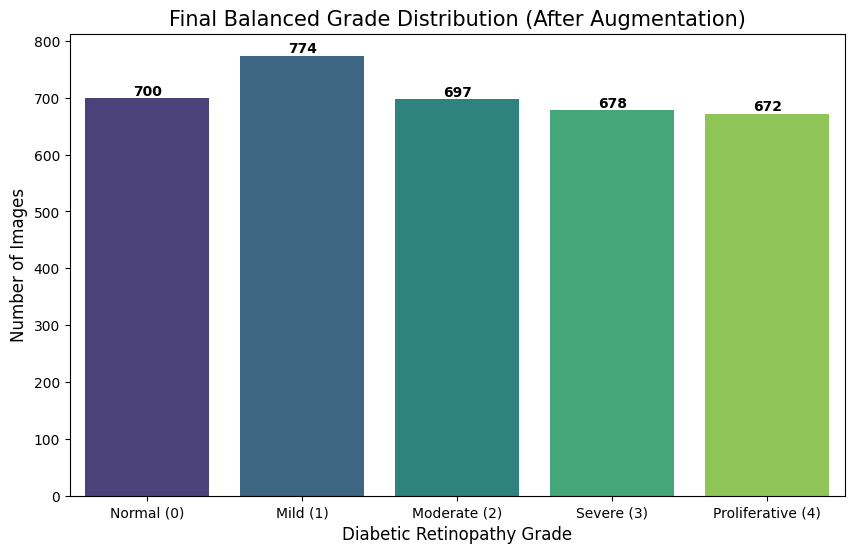

In [9]:
# ==========================================
# 4. FINAL DATASET SUMMARY
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Load the final balanced CSV
final_df = pd.read_csv('../Data_CSV/ODIR_Train_Balanced.csv')

# 1. Print Numerical Distribution
print("--- Final Balanced Dataset Distribution ---")
distribution = final_df['Grade'].value_counts().sort_index()
print(distribution)
print(f"\nTotal Training Images: {len(final_df)}")

# 2. Visualize the Distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=distribution.index, y=distribution.values, palette='viridis')

plt.title('Final Balanced Grade Distribution (After Augmentation)', fontsize=15)
plt.xlabel('Diabetic Retinopathy Grade', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['Normal (0)', 'Mild (1)', 'Moderate (2)', 'Severe (3)', 'Proliferative (4)'])

# Add labels on top of bars
for i, v in enumerate(distribution.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.show()